In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
raw_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\interventorias\jun026.csv',sep=',',encoding='latin1') #Name the file as export
raw_datam=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\interventorias\jun026_col.csv',sep=',',encoding='latin1') #Name the file as export_columns
raw_datam.rename(columns={'Unnamed: 1':'Message Type',
                                 'Unnamed: 2':'Protocole',
                                 'Unnamed: 3':'IMEI',
                                 'Unnamed: 4':'Serial',
                                 'Unnamed: 5':'Mileage',
                                 'Unnamed: 6':'Date',
                                 'Unnamed: 7':'Ignition',
                                 'Unnamed: 8':'Latitude',
                                 'Unnamed: 9':'Longitude',
                                 'Unnamed: 10':'Altitude',
                                 'Unnamed: 11':'External Power',
                                 'Unnamed: 12':'RPM',
                                 'Unnamed: 13':'Speed',
                                 'Unnamed: 14':'Satellite Number',
                                 'Unnamed: 15':'Azimuth',
                                 'Unnamed: 16':'Battery level',
                                 },inplace=True)
raw_datam.info()
raw_datam.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\interventorias\export_named.csv')

<class 'pandas.DataFrame'>
RangeIndex: 1177 entries, 0 to 1176
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Message           1177 non-null   str  
 1   Message Type      1177 non-null   str  
 2   Protocole         1177 non-null   str  
 3   IMEI              1177 non-null   str  
 4   Serial            1177 non-null   str  
 5   Mileage           1177 non-null   str  
 6   Date              1177 non-null   str  
 7   Ignition          1177 non-null   str  
 8   Latitude          1177 non-null   str  
 9   Longitude         1177 non-null   str  
 10  Altitude          1177 non-null   str  
 11  External Power    1164 non-null   str  
 12  RPM               1164 non-null   str  
 13  Speed             1149 non-null   str  
 14  Satellite Number  1149 non-null   str  
 15  Azimuth           1149 non-null   str  
 16  Battery level     1149 non-null   str  
 17  Unnamed: 17       1149 non-null   str  
 18 

In [18]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\interventorias\export_named.csv',sep=',')
unit['Odometer in meters']=0.0
unit.info()
#unit_mileage=unit[unit['Date'].str.contains('2026-04-16T15')]
#unit_mileage[['Mileage','Date','IMEI']]

<class 'pandas.DataFrame'>
RangeIndex: 1177 entries, 0 to 1176
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1177 non-null   int64  
 1   Message             1177 non-null   str    
 2   Message Type        1177 non-null   str    
 3   Protocole           1177 non-null   str    
 4   IMEI                1177 non-null   str    
 5   Serial              1177 non-null   str    
 6   Mileage             1177 non-null   str    
 7   Date                1177 non-null   str    
 8   Ignition            1177 non-null   str    
 9   Latitude            1177 non-null   str    
 10  Longitude           1177 non-null   str    
 11  Altitude            1177 non-null   str    
 12  External Power      1164 non-null   str    
 13  RPM                 1164 non-null   str    
 14  Speed               1149 non-null   str    
 15  Satellite Number    1149 non-null   str    
 16  Azimuth          

In [19]:
unit_odometer=unit[~unit['Protocole'].str.contains(':0')]
unit_odometer['Protocole'].value_counts()
#print("Unit odometer rows: ",unit_odometer.shape[0])

Protocole
ProtocolHeadType:19    1062
ProtocolHeadType:20      87
Name: count, dtype: int64

Odometer

Date:"2026-05-31T00:16:51Z"  ->  0 2075542.0
Date:"2026-05-31T01:16:51Z"  ->  1 2075542.0
Date:"2026-05-31T02:16:50Z"  ->  2 2075542.0
Date:"2026-05-31T03:16:51Z"  ->  3 2075542.0
Date:"2026-05-31T04:16:51Z"  ->  4 2075542.0
Date:"2026-05-31T05:16:51Z"  ->  5 2075542.0
Date:"2026-05-31T06:16:51Z"  ->  6 2075542.0
Date:"2026-05-31T07:16:50Z"  ->  7 2075542.0
Date:"2026-05-31T08:16:51Z"  ->  8 2075542.0
Date:"2026-05-31T09:16:51Z"  ->  9 2075542.0
Date:"2026-05-31T10:16:51Z"  ->  10 2075542.0
Date:"2026-05-31T11:16:51Z"  ->  11 2075542.0
Date:"2026-05-31T12:16:50Z"  ->  12 2075542.0
Date:"2026-05-31T13:16:51Z"  ->  13 2075542.0
Date:"2026-05-31T14:16:51Z"  ->  14 2075542.0
Date:"2026-05-31T15:16:51Z"  ->  15 2075542.0
Date:"2026-05-31T16:16:51Z"  ->  16 2075542.0
Date:"2026-05-31T17:16:50Z"  ->  17 2075542.0
Date:"2026-05-31T18:16:51Z"  ->  18 2075542.0
Date:"2026-05-31T19:16:51Z"  ->  19 2075542.0
Date:"2026-05-31T20:16:51Z"  ->  20 2075542.0
Date:"2026-05-31T21:16:51Z"  ->  21 2075542.

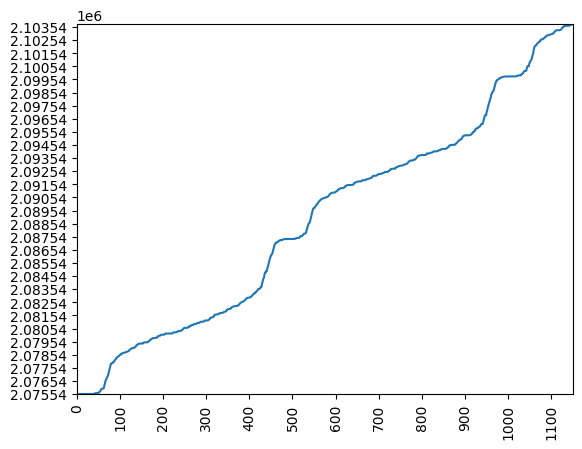

In [20]:
y_axis=[]
x_axis=[]
date=[]

for i in range(0,unit_odometer.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit_odometer.iloc[i,6][8:15]))
    x_axis.append(i)
    date.append(unit_odometer.iloc[i,7])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,unit_odometer.shape[0]):
    print(date[i],' -> ',x_axis[i],y_axis[i])

plt.ylim(2075542,2103744)
plt.xlim(0,1150)
plt.yticks(range(2075542,2103744,1000))
plt.xticks(range(0,1150,100),rotation=90)
plt.plot(x_axis,y_axis)

Speed

Date:"2026-06-01T11:29:56Z"  ->  73.0
Date:"2026-06-01T11:31:31Z"  ->  78.0
Date:"2026-06-01T11:32:06Z"  ->  75.0
Date:"2026-06-01T11:33:31Z"  ->  74.0
Date:"2026-06-01T11:35:14Z"  ->  76.0
Date:"2026-06-01T11:35:29Z"  ->  73.0
Date:"2026-06-01T11:35:55Z"  ->  76.0
Date:"2026-06-01T11:36:54Z"  ->  75.0
Date:"2026-06-01T11:37:09Z"  ->  75.0
Date:"2026-06-01T11:38:13Z"  ->  77.0
Date:"2026-06-01T11:39:27Z"  ->  76.0
Date:"2026-06-01T11:40:16Z"  ->  76.0
Date:"2026-06-01T11:41:31Z"  ->  76.0
Date:"2026-06-01T11:42:31Z"  ->  75.0
Date:"2026-06-01T11:43:31Z"  ->  76.0
Date:"2026-06-01T22:14:25Z"  ->  76.0
Date:"2026-06-01T22:15:32Z"  ->  76.0
Date:"2026-06-01T22:16:32Z"  ->  76.0
Date:"2026-06-01T22:17:32Z"  ->  76.0
Date:"2026-06-01T22:18:57Z"  ->  74.0
Date:"2026-06-01T22:20:32Z"  ->  75.0
Date:"2026-06-01T22:21:32Z"  ->  76.0
Date:"2026-06-01T22:21:32Z"  ->  76.0
Date:"2026-06-01T22:22:32Z"  ->  75.0
Date:"2026-06-01T22:22:32Z"  ->  75.0
Date:"2026-06-01T22:22:32Z"  ->  75.0
Date:"2026-0

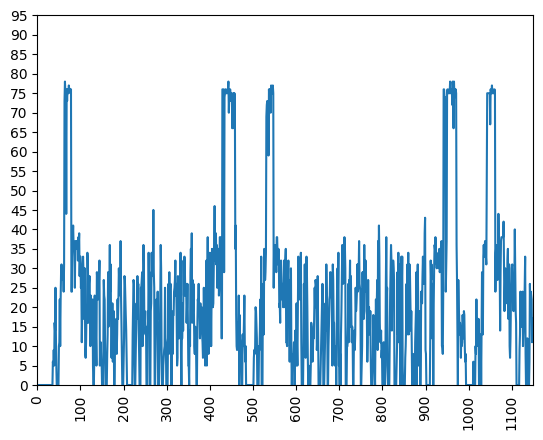

In [28]:
y_axis=[]
x_axis=[]
date=[]

for i in range(0,unit_odometer.shape[0]):
    y_axis.append(float(unit_odometer.iloc[i,14][6:9]))
    x_axis.append(i)
    date.append(unit_odometer.iloc[i,7])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,unit_odometer.shape[0]):
    if y_axis[i]>65:
        print(date[i],' -> ',y_axis[i])#,y_axis[i])

plt.ylim(0,50)
plt.xlim(0,1150)
plt.yticks(range(0,100,5))
plt.xticks(range(0,1150,100),rotation=90)
plt.plot(x_axis,y_axis)

In/outs

PS I0 I1 I2 I3 I4 I5 DI0
15 14 13 12 11 10 09 08 07 06 05 04 03 02 01 00 
          1  0  0  0  0  0  0  0  0  0  0  0  0
          1  0  0  0  0  0  0  0  0  0  0  0  0
          1  0  0  0  0  0  0  0  0  0  0  0  0

In [22]:
#TopFly Pioneer.
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
raw_data_df=pd.DataFrame()
#cad='0x252513005900CE0869487064575128003C38402D000000644800000007000041000000FFFFFFFFFFFFFFFFFFFF00D500053670102604241257539A09BB44EE0997C2413ECB40000000F803312481FFFFFF0000190001FFFFFFx252514005908F40869487060215778003C38402D00000059500000000000002000000000000000FFFFFFFFFFFF42D50000AED51026042021294000E07E445A0D99C219C95D400000000003611173FFFFFF00001F0000FFFFFF'
#print(cad[106:118], cad[64:68], raw_data.shape[0])

for i in range(0,raw_data.shape[0]):
    long_cad=len(raw_data.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(raw_data.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])       
    print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

print("len aux_cad: ",len(aux_cad))

2000 0b10000000000000 260531001651 0x252513005925B50869487064447005003C0E102D000028604F00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5013CB3DF0026053100165166661643C32E95C21F34BF40000000C903911274FFFFFF0000250000FFFFFF
2000 0b10000000000000 260531011651 0x252513005925B60869487064447005003C0E102D000028604F00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5013CB3DF0026053101165166661643C32E95C21F34BF40000000C903911274FFFFFF0000240000FFFFFF
2000 0b10000000000000 260531021650 0x252513005925B70869487064447005003C0E102D000028605000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5013CB3DF0026053102165066661643C32E95C21F34BF40000000C903911273FFFFFF0000230000FFFFFF
2000 0b10000000000000 260531031651 0x252513005925B80869487064447005003C0E102D000028604E00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5013CB3DF0026053103165166661643C32E95C21F34BF40000000C903911272FFFFFF0000220000FFFFFF
2000 0b10000000000000 260531041651 0x252513005925B90869487064447005003C0E102D0000285D4E00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5013CB

Satellites

In [23]:
date=[]
satellite_number=[]
for i in range(0,unit_odometer.shape[0]):   
    date.append(unit_odometer.iloc[i,7])
    satellite_number.append(int(unit_odometer.iloc[i,15][16:18]))

for i in range(0,unit_odometer.shape[0]):
    if satellite_number[i]<5:
        print(date[i],' -> ',satellite_number[i])

Power

In [24]:
date=[]
battery=[]
external_power=[]
inner_battery=[]
battery_df=unit_odometer[unit_odometer['Battery level'].str.contains('BatteryLevel')]

for i in range(0,battery_df.shape[0]):   
    date.append(battery_df.iloc[i,7])
    battery.append(int(battery_df.iloc[i,17][13:15]))
    external_power.append(float(battery_df.iloc[i,12][21:26]))

for i in range(0,battery_df.shape[0]):
    if external_power[i]<5:
        print(date[i],' -> ',external_power[i])

In [25]:
int_bat_vol_1=raw_data[raw_data['Status'].str.contains('0x252514')]
int_bat_vol_2=raw_data[raw_data['Status'].str.contains('0x252513')]
int_bat_vol=pd.concat([int_bat_vol_1,int_bat_vol_2])
int_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

for i in range(0,int_bat_vol.shape[0]):
    val=(float(int_bat_vol.iloc[i,2][150:154]))/100
    date_bat.append(int_bat_vol.iloc[i,2][106:119])
    int_bat.append(val)

for i in range(0,int_bat_vol.shape[0]):
    if int_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=int_bat

print(bat_df)

Empty DataFrame
Columns: []
Index: []


Pánico

In [26]:
aux_cad=[]
aux_date=[]
aux_raw_data=[]
#cad='0x252513005900CE0869487064575128003C38402D000000644800000007000041000000FFFFFFFFFFFFFFFFFFFF00D500053670102604241257539A09BB44EE0997C2413ECB40000000F803312481FFFFFF0000190001FFFFFFx252514005908F40869487060215778003C38402D00000059500000000000002000000000000000FFFFFFFFFFFF42D50000AED51026042021294000E07E445A0D99C219C95D400000000003611173FFFFFF00001F0000FFFFFF'
#print(cad[106:118], cad[64:68], raw_data.shape[0])

for i in range(0,raw_data.shape[0]):
    long_cad=len(raw_data.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(raw_data.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][92:94]
    #print(aux_value)#, ' -> ',aux_date[i])
    aux_date.append(aux_cad[i][106:118])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])